In [1]:
import pandas as pd
import os as os
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import matplotlib.style as style

Matplotlib is building the font cache; this may take a moment.


## 01. Generate list of taxa seen in all ASV data

In [3]:
# 18S genera
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/18S comparison")
tax_freq_18S = pd.read_csv("18S_frequencies_all_tax_ranks.csv")
genera_18S = list(tax_freq_18S['Genus'].unique())
phyla_genera_18S = tax_freq_18S.groupby(['Phylum','Genus']).size().reset_index().rename(columns={0:'number of occurrences'})

In [4]:
len(tax_freq_18S['18S sample'].unique())

215

In [5]:
tax_freq_18S_avg = tax_freq_18S.groupby(['Phylum'], as_index=False)['18S reads'].agg('sum')
tax_freq_18S_avg['Percent composition'] = tax_freq_18S_avg['18S reads'] / 225
tax_freq_18S_avg['Data set'] = '18S'
tax_freq_18S_avg_sort = tax_freq_18S_avg.sort_values(by='Percent composition', ascending=False).drop(columns='18S reads')
tax_freq_18S_avg_sort.head()

,Phylum,Percent composition,Data set
29,Dinophyceae,0.270544,18S
4,Arthropoda,0.203103,18S
6,Bacillariophyta,0.157348,18S
66,unknown,0.097693,18S
54,Polycystinea,0.024122,18S


In [7]:
tax_freq_18S_avg_sort['Phylum'] = tax_freq_18S_avg_sort['Phylum'].replace({'Dinophyceae':'Dinophyta'})
tax_freq_18S_avg_sort[tax_freq_18S_avg_sort['Phylum'] == 'Ascomycota']

,Phylum,Percent composition,Data set
5,Ascomycota,0.001758,18S


In [8]:
pivot_18S = pd.pivot_table(data=tax_freq_18S_avg_sort, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='Percent composition').fillna(0)
#pivot_18S_sub = pivot_18S[pivot_18S > 0.001].dropna(axis='columns')
pivot_18S_sort = pivot_18S.sort_values(by='18S', axis=1, ascending=False)

In [9]:
pivot_18S_sort

Phylum,Dinophyta,Arthropoda,Bacillariophyta,unknown,Polycystinea,Ciliophora,Chlorophyta,Chordata,Haptophyta,Euglenozoa,...,Platyhelminthes,Hemimastigophora,Filasterea,Zoopagomycota,Cryptomycota,Breviatea,Gastrotricha,Aphelidea,Evosea,Eustigmatophyceae
Data set,,,,,,,,,,,,,,,,,,,,,
18S,0.270544,0.203103,0.157348,0.097693,0.024122,0.020479,0.015839,0.015665,0.013993,0.012955,...,0.000001,8.182160e-07,5.103671e-07,5.006264e-07,1.442132e-07,1.396643e-07,5.578917e-08,5.483448e-08,4.632477e-08,3.567542e-08


<Figure size 1000x1200 with 0 Axes>

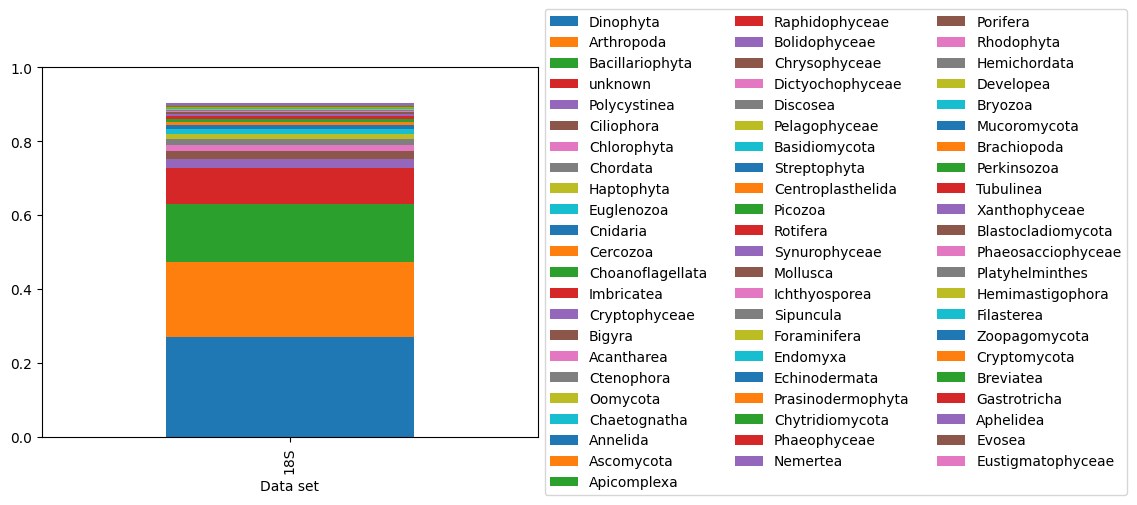

In [9]:
fig = plt.figure(figsize=(10,12))

pivot_18S_sort.plot(kind='bar', stacked=True)

# Put a legend to the right of the current axis
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=3)

plt.ylim(0, 1.0)

#plt.ylabel('Average % eukaryotic bps, reads, or ORFs', size=14)
#plt.xlabel('Sequence data set', size=16)
#plt.xticks(rotation=45, ha='right', size=14)

#plt.savefig('eCruises2018_2019_prok_vs_euk_reads.png', format='png', 
#            dpi=1200, bbox_inches='tight')
# show the graph
plt.show()

##### Extract unique genera

In [10]:
tax_freq_18S

,Unnamed: 0,Domain,Phylum,Class,Order,Family,Genus,18S sample,18S reads
0,0,Eukaryota,Bacillariophyta,Bacillariophyceae,Bacillariales,Bacillariaceae,Pseudo-nitzschia,CN18FESPkoa_SC24,0.139950
1,1,Eukaryota,Polycystinea,Polycystinea,NaN,NaN,NaN,CN18FESPkoa_SC24,0.162243
2,2,Eukaryota,Dinophyceae,Dinophyceae,Gymnodiniales,Gymnodiniaceae,Akashiwo,CN18FESPkoa_SC24,0.000058
3,3,Eukaryota,unknown,unknown,unknown,unknown,unknown,CN18FESPkoa_SC24,0.000879
4,4,Eukaryota,Bacillariophyta,NaN,NaN,NaN,NaN,CN18FESPkoa_SC24,0.011125
...,...,...,...,...,...,...,...,...,...
1211781,662475,Eukaryota,Oomycota,Lagenidiales,Lagenidiales,Haliphthoraceae,Haliphthoros,CN19_Nisk_SM_Day_5m_2,0.000000
1211782,662476,Eukaryota,Platyhelminthes,Rhabditophora,Proseriata,unknown,g_,CN19_Nisk_SM_Day_5m_2,0.000000
1211783,662477,Eukaryota,Chlorophyta,Trebouxiophyceae,Trebouxiales,Trebouxiaceae,g_,CN19_Nisk_SM_Day_5m_2,0.000000
1211784,662478,Eukaryota,Arthropoda,Malacostraca,Amphipoda,Hyperiidae,g_,CN19_Nisk_SM_Day_5m_2,0.000000


In [11]:
phyla_class_genera_18S = tax_freq_18S.groupby(['Phylum', 'Class', 'Order', 'Family', 'Genus']).size().reset_index().rename(columns={0:'number of occurrences'})
phylum = phyla_class_genera_18S[phyla_class_genera_18S['Phylum'] == 'Haptophyta']
phylum.shape

(16, 6)

In [12]:
phylum.sort_values(by=['number of occurrences'], ascending=False)

,Phylum,Class,Order,Family,Genus,number of occurrences
696,Haptophyta,Prymnesiales,Prymnesiales,Chrysochromulinaceae,Chrysochromulina,5187
697,Haptophyta,Prymnesiales,Prymnesiales,Chrysochromulinaceae,g_,1287
694,Haptophyta,Phaeocystales,Phaeocystales,Phaeocystaceae,Phaeocystis,1124
695,Haptophyta,Phaeocystales,Phaeocystales,Phaeocystaceae,g_,1102
700,Haptophyta,Prymnesiales,Prymnesiales,Prymnesiaceae,g_,997
702,Haptophyta,Zygodiscales,Zygodiscales,Braarudosphaeraceae,Braarudosphaera,853
699,Haptophyta,Prymnesiales,Prymnesiales,Prymnesiaceae,Prymnesium,471
690,Haptophyta,Coccolithales,Coccolithales,Pleurochrysidaceae,g_,271
701,Haptophyta,Prymnesiales,Prymnesiales,unknown,Chrysocampanula,215
698,Haptophyta,Prymnesiales,Prymnesiales,Prymnesiaceae,Haptolina,215


#### Extract specific class

In [13]:
phyla_class_18S = tax_freq_18S.groupby(['Phylum', 'Class']).size().reset_index().rename(columns={0:'number of occurrences'})
clAss = phyla_class_18S[phyla_class_18S['Phylum'] == 'Arthropoda'].sort_values(by=['number of occurrences'], ascending=False)
clAss['percent'] = clAss['number of occurrences'] / clAss['number of occurrences'].sum()
clAss.head()

,Phylum,Class,number of occurrences,percent
6,Arthropoda,Hexanauplia,16539,0.674071
7,Arthropoda,Malacostraca,7152,0.291490
9,Arthropoda,Pycnogonida,360,0.014672
10,Arthropoda,Thecostraca,263,0.010719
5,Arthropoda,Branchiopoda,111,0.004524


In [14]:
# COI genera
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/COI comparison")
tax_freq_COI = pd.read_csv("COI_frequencies_all_tax_ranks.csv")
genera_COI = list(tax_freq_COI['Genus'].unique())
phyla_genera_COI = tax_freq_COI.groupby(['Phylum','Genus']).size().reset_index().rename(columns={0:'number of occurrences'})

In [15]:
phylum = phyla_genera_COI[phyla_genera_COI['Phylum'] == 'Arthropoda']
phylum.shape

(35, 3)

In [16]:
len(tax_freq_COI['COI sample'].unique())

215

In [17]:
len(genera_COI)

210

In [18]:
tax_freq_COI_avg = tax_freq_COI.groupby(['Phylum'], as_index=False)['COI reads'].agg('sum')
tax_freq_COI_avg['Percent composition'] = tax_freq_COI_avg['COI reads'] / 225
tax_freq_COI_avg['Data set'] = 'COI'
tax_freq_COI_avg_sort = tax_freq_COI_avg.sort_values(by='Percent composition', ascending=False).drop(columns='COI reads')
tax_freq_COI_avg_sort.head()

,Phylum,Percent composition,Data set
26,Haptophyta,0.255984,COI
4,Bacillariophyta,0.196363,COI
2,Arthropoda,0.163684,COI
34,Oomycota,0.100290,COI
38,Picozoa,0.034358,COI


In [19]:
tax_freq_COI_avg_sort['Phylum'] = tax_freq_COI_avg_sort['Phylum'].replace({'Dinophyceae':'Dinophyta'})

In [20]:
tax_freq_COI_avg_sort[tax_freq_COI_avg_sort['Phylum'] == 'Ascomycota']

,Phylum,Percent composition,Data set
3,Ascomycota,0.003589,COI


In [21]:
pivot_COI = pd.pivot_table(data=tax_freq_COI_avg_sort, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='Percent composition').fillna(0)
pivot_COI_sort = pivot_COI.sort_values(by='COI', axis=1, ascending=False)

In [22]:
pivot_COI_sort

Phylum,Haptophyta,Bacillariophyta,Arthropoda,Oomycota,Picozoa,Phaeophyceae,Cnidaria,Chlorophyta,Rotifera,Discosea,...,Sipuncula,Hemichordata,Zoopagomycota,Phoronida,Xenacoelomorpha,Ciliophora,Ichthyosporea,Platyhelminthes,Onychophora,Glaucocystophyceae
Data set,,,,,,,,,,,,,,,,,,,,,
COI,0.255984,0.196363,0.163684,0.10029,0.034358,0.025728,0.023701,0.01495,0.008624,0.006931,...,0.000011,0.000004,0.000001,0.000001,7.897584e-07,7.511871e-07,7.055117e-07,4.883951e-07,3.369562e-07,1.543210e-07


<Figure size 1000x1200 with 0 Axes>

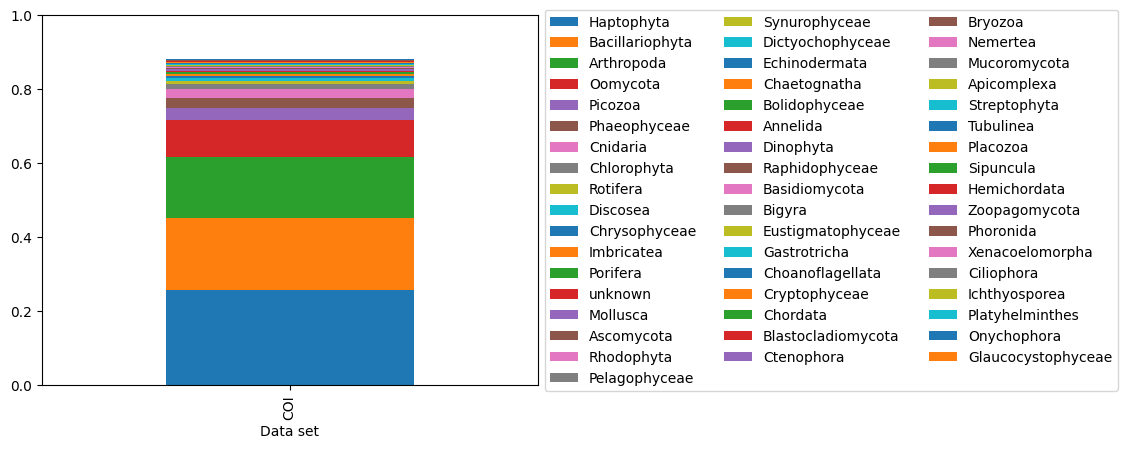

In [29]:
fig = plt.figure(figsize=(10,12))

pivot_COI_sort.plot(kind='bar', stacked=True)

# Put a legend to the right of the current axis
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=3)

plt.ylim(0, 1.0)

#plt.ylabel('Average % eukaryotic bps, reads, or ORFs', size=14)
#plt.xlabel('Sequence data set', size=16)
#plt.xticks(rotation=45, ha='right', size=14)

#plt.savefig('eCruises2018_2019_prok_vs_euk_reads.png', format='png', 
#            dpi=1200, bbox_inches='tight')
# show the graph
plt.show()

##### Extract genera in specific phylum

In [32]:
phyla_class_genera_COI = tax_freq_COI.groupby(['Phylum', 'Class', 'Order', 'Family', 'Genus']).size().reset_index().rename(columns={0:'number of occurrences'})
phylum = phyla_class_genera_COI[phyla_class_genera_COI['Phylum'] == 'Haptophyta']
phylum.shape

(8, 6)

In [33]:
phylum.sort_values(by=['number of occurrences'], ascending=False)

,Phylum,Class,Order,Family,Genus,number of occurrences
474,Haptophyta,Prymnesiales,Prymnesiales,Chrysochromulinaceae,g_,162638
473,Haptophyta,Phaeocystales,Phaeocystales,Phaeocystaceae,g_,98726
471,Haptophyta,Isochrysidales,Isochrysidales,Noelaerhabdaceae,g_,51339
472,Haptophyta,Phaeocystales,Phaeocystales,Phaeocystaceae,Phaeocystis,18522
470,Haptophyta,Isochrysidales,Isochrysidales,Noelaerhabdaceae,Emiliania,3622
469,Haptophyta,Isochrysidales,Isochrysidales,Isochrysidaceae,g_,2037
475,Haptophyta,unknown,unknown,unknown,g_,104
476,Haptophyta,unknown,unknown,unknown,unknown,104


In [32]:
phyla_class_COI = tax_freq_COI.groupby(['Phylum','Class']).size().reset_index().rename(columns={0:'number of occurrences'})
clAss = phyla_class_COI[phyla_class_COI['Phylum'] == 'Arthropoda'].sort_values(by=['number of occurrences'], ascending=False)
clAss['percent'] = clAss['number of occurrences'] / clAss['number of occurrences'].sum()
clAss.head()

,Phylum,Class,number of occurrences,percent
8,Arthropoda,Hexanauplia,100123,0.798525
10,Arthropoda,Malacostraca,15487,0.123516
9,Arthropoda,Insecta,6448,0.051426
14,Arthropoda,unknown,968,0.007720
4,Arthropoda,Arachnida,896,0.007146


In [283]:
phylum.to_csv("COI_unique_arthropoda_genera.csv", index=None)

#### Label data sets

In [23]:
phyla_genera_18S['Data set'] = '18S'
phyla_genera_COI['Data set'] = 'COI'

## 2. Get metagenome taxa list

In [25]:
# metagenomes
os.chdir("/Users/nastassiapatin/GitHub/Euk-eDNA-comparison/Diversity comparisons")
mgns = pd.read_csv("CCE_2018-2019_mmseqs_euk_lineage_counts.csv")
mgns.head(3)

,count,Phylum,Class,Order,Family,Genus,Species,Kingdom,Metagenome sample
0,1,Bolidophyceae,Bolidophyceae,Parmales,Triparmaceae,Triparma,NaN,NaN,D0079A
1,1,Pelagophyceae,Pelagophyceae,Pelagomonadales,NaN,Pelagomonas,Pelagomonas calceolata,NaN,D0079A
2,1,Chlorophyta,Trebouxiophyceae,NaN,NaN,Coccomyxa,Coccomyxa sp. Obi,Viridiplantae,D0079A


#### Generate phylum lists and average # genes across all metagenomes

In [26]:
# Sum the number of observations for each phylum 
phyla_mgns = mgns.groupby(['Phylum']).size().reset_index().rename(columns={0:'number of occurrences'})

# Assign 'metagenome' as data set
phyla_mgns['Data set'] = 'Mgn'

# Calculate the percent of metagenome represented by each phylum
phyla_mgns['Percent composition'] = phyla_mgns['number of occurrences'] / phyla_mgns['number of occurrences'].sum()
phyla_mgns = phyla_mgns.drop(columns='number of occurrences')

In [27]:
phyla_mgns

,Phylum,Data set,Percent composition
0,Acantharea,Mgn,6.378876e-06
1,Acanthocephala,Mgn,3.752280e-07
2,Actinophryidae,Mgn,1.688526e-06
3,Ancyromonadida,Mgn,4.877964e-06
4,Annelida,Mgn,1.412358e-03
...,...,...,...
90,Tsukubamonadida,Mgn,2.626596e-06
91,Tubulinea,Mgn,7.086180e-04
92,Xanthophyceae,Mgn,1.169773e-03
93,Xenacoelomorpha,Mgn,7.879787e-06


In [28]:
phyla_mgns.sort_values(by='Percent composition', ascending=False)

,Phylum,Data set,Percent composition
21,Chlorophyta,Mgn,1.901730e-01
47,Haptophyta,Mgn,1.698681e-01
10,Bacillariophyta,Mgn,1.593642e-01
8,Arthropoda,Mgn,6.289252e-02
86,Streptophyta,Mgn,6.137360e-02
...,...,...,...
16,Breviatea,Mgn,9.380699e-07
45,Gastrotricha,Mgn,7.504559e-07
1,Acanthocephala,Mgn,3.752280e-07
38,Entoprocta,Mgn,3.752280e-07


In [29]:
phyla_mgns['Phylum'] = phyla_mgns['Phylum'].replace({'Dinophyceae':'Dinophyta'})

In [30]:
phyla_mgns[phyla_mgns['Phylum'] == 'Ascomycota']

,Phylum,Data set,Percent composition
9,Ascomycota,Mgn,0.023549


In [31]:
# number of unique genera in the metagenomes
genera_mgns = list(mgns['Genus'].unique())
len(genera_mgns)

6237

In [32]:
pivot = pd.pivot_table(data=phyla_mgns, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='Percent composition').fillna(0)

In [33]:
pivot_sub = pivot[pivot > 0.001].dropna(axis='columns')
pivot_sub_sort = pivot_sub.sort_values(by='Mgn', axis=1, ascending=False)

In [34]:
pivot_sub_sort

Phylum,Chlorophyta,Haptophyta,Bacillariophyta,Arthropoda,Streptophyta,Dinophyta,Pelagophyceae,Chordata,Ciliophora,Ascomycota,...,Porifera,Phaeophyceae,Pinguiophyceae,Choanoflagellata,Discosea,Annelida,Evosea,Xanthophyceae,Endomyxa,Perkinsozoa
Data set,,,,,,,,,,,,,,,,,,,,,
Mgn,0.190173,0.169868,0.159364,0.062893,0.061374,0.050709,0.049149,0.048216,0.031393,0.023549,...,0.001782,0.001616,0.001514,0.001499,0.001422,0.001412,0.001282,0.00117,0.00114,0.001085


<Figure size 1000x1200 with 0 Axes>

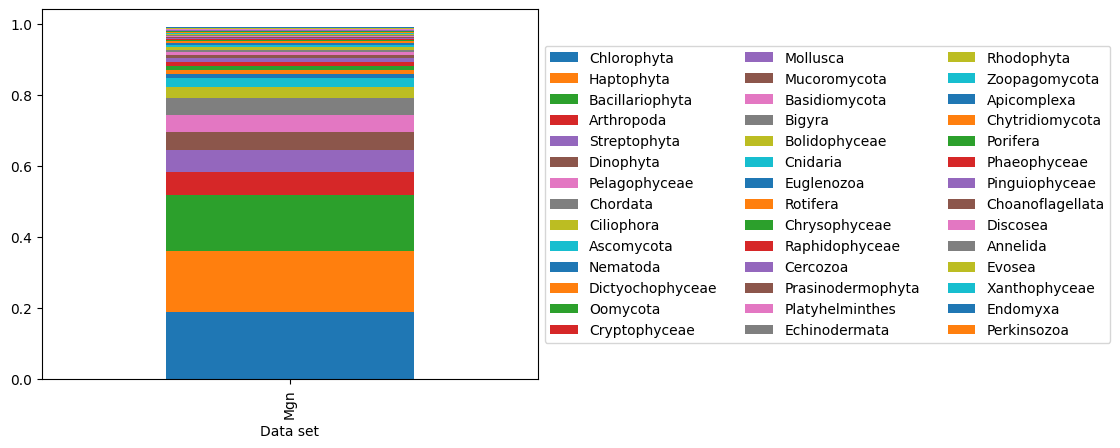

In [51]:
fig = plt.figure(figsize=(10,12))

pivot_sub_sort.plot(kind='bar', stacked=True)

# Put a legend to the right of the current axis
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=3)

#plt.ylabel('Average % eukaryotic bps, reads, or ORFs', size=14)
#plt.xlabel('Sequence data set', size=16)
#plt.xticks(rotation=45, ha='right', size=14)

#plt.savefig('eCruises2018_2019_prok_vs_euk_reads.png', format='png', 
#            dpi=1200, bbox_inches='tight')
# show the graph
plt.show()

#### Get genus-level annotations

In [108]:
phyla_genera_class_mgns = mgns.groupby(['Phylum', 'Class', 'Order', 'Family', 'Genus']).size().reset_index().rename(columns={0:'number of occurrences'})
phyla_genera_mgns = mgns.groupby(['Phylum','Genus']).size().reset_index().rename(columns={0:'number of occurrences'})
phyla_genera_mgns['Data set'] = 'Mgn'

In [109]:
phyla_genera_mgns.head()

,Phylum,Genus,number of occurrences,Data set
0,Acantharea,Astrolonche,25,Mgn
1,Acantharea,Phyllostaurus,5,Mgn
2,Acantharea,Stauracon,4,Mgn
3,Acanthocephala,Pomphorhynchus,2,Mgn
4,Actinophryidae,Actinophrys,6,Mgn


#### Extract specific phylum

In [73]:
phylum = phyla_genera_class_mgns[phyla_genera_class_mgns['Phylum'] == 'Bacillariophyta'].sort_values(by=['number of occurrences'], 
                                                                                                ascending=False)

In [74]:
phylum[phylum['Genus'] == 'unknown']

,Phylum,Class,Order,Family,Genus,number of occurrences


#### Get class-level annotations

In [27]:
phyla_class_mgns = mgns.groupby(['Phylum','Class']).size().reset_index().rename(columns={0:'number of occurrences'})
clAss = phyla_class_mgns[phyla_class_mgns['Phylum'] == 'Arthropoda'].sort_values(by=['number of occurrences'], ascending=False)
clAss.head()

,Phylum,Class,number of occurrences
22,Arthropoda,Insecta,157899
20,Arthropoda,Hexanauplia,75099
13,Arthropoda,Arachnida,54045
23,Arthropoda,Malacostraca,21413
14,Arthropoda,Branchiopoda,9037


In [28]:
clAss['Percent composition'] = clAss['number of occurrences'] /clAss['number of occurrences'].sum()
clAss.head()

,Phylum,Class,number of occurrences,Percent composition
22,Arthropoda,Insecta,157899,0.471027
20,Arthropoda,Hexanauplia,75099,0.224027
13,Arthropoda,Arachnida,54045,0.161221
23,Arthropoda,Malacostraca,21413,0.063877
14,Arthropoda,Branchiopoda,9037,0.026958


In [281]:
phylum.to_csv("metagenomes_unique_chordata_genera.csv", index=None)

### Group by class

In [36]:
# Sum the number of observations for each phylum 
phyla_mgns_class = mgns.groupby(['Phylum','Class']).size().reset_index().rename(columns={0:'number of occurrences'})
#phyla_mgns_class_arth = phyla_mgns_class[phyla_mgns_class['Phylum'] == 'Streptophyta']

# Calculate the percent of metagenome represented by each phylum
#phyla_mgns_class_arth['Percent composition'] = phyla_mgns_class_arth['number of occurrences'] / phyla_mgns_class_arth['number of occurrences'].sum()
#phyla_mgns_class_arth = phyla_mgns_class_arth.drop(columns='number of occurrences')
#phyla_mgns_class_arth.head()

In [37]:
phyla_mgns_class.head()

,Phylum,Class,number of occurrences
0,Acantharea,Acantharea,34
1,Acanthocephala,Palaeacanthocephala,2
2,Actinophryidae,Actinophryidae,9
3,Ancyromonadida,Ancyromonadida,26
4,Annelida,Clitellata,1147


In [38]:
phyla_genera_class_mgns.shape

(5903, 6)

In [39]:
phyla_genera_class_mgns.head()

,Phylum,Class,Order,Family,Genus,number of occurrences
0,Acantharea,Acantharea,Arthracanthida,Phyllostauridae,Phyllostaurus,5
1,Acantharea,Acantharea,Chaunacanthida,Stauraconidae,Stauracon,4
2,Acantharea,Acantharea,Symphyacanthida,Astrolithidae,Astrolonche,25
3,Acanthocephala,Palaeacanthocephala,Echinorhynchida,Pomphorhynchidae,Pomphorhynchus,2
4,Ancyromonadida,Ancyromonadida,Ancyromonadida,Ancyromonadidae,Ancyromonas,11


### Filter out insects and arachnids

In [40]:
phy_gen_class_filt = phyla_genera_class_mgns[(phyla_genera_class_mgns['Class'] != 'Insecta') & (phyla_genera_class_mgns['Class'] != 'Arachnida')]
phy_gen_class_filt.shape

(4636, 6)

In [41]:
phy_gen_class_filt

,Phylum,Class,Order,Family,Genus,number of occurrences
0,Acantharea,Acantharea,Arthracanthida,Phyllostauridae,Phyllostaurus,5
1,Acantharea,Acantharea,Chaunacanthida,Stauraconidae,Stauracon,4
2,Acantharea,Acantharea,Symphyacanthida,Astrolithidae,Astrolonche,25
3,Acanthocephala,Palaeacanthocephala,Echinorhynchida,Pomphorhynchidae,Pomphorhynchus,2
4,Ancyromonadida,Ancyromonadida,Ancyromonadida,Ancyromonadidae,Ancyromonas,11
...,...,...,...,...,...,...
5898,Zoopagomycota,Kickxellomycetes,Kickxellales,Kickxellaceae,Spiromyces,2
5899,Zoopagomycota,Zoopagomycetes,Zoopagales,Helicocephalidaceae,Rhopalomyces,1
5900,Zoopagomycota,Zoopagomycetes,Zoopagales,Piptocephalidaceae,Piptocephalis,243
5901,Zoopagomycota,Zoopagomycetes,Zoopagales,Piptocephalidaceae,Syncephalis,303


In [30]:
phyla_genera_mgns_filt = phy_gen_class_filt.groupby(['Phylum','Genus']).size().reset_index().rename(columns={0:'number of occurrences'})
phyla_genera_mgns_filt.head()

,Phylum,Genus,number of occurrences
0,Acantharea,Astrolonche,1
1,Acantharea,Phyllostaurus,1
2,Acantharea,Stauracon,1
3,Acanthocephala,Pomphorhynchus,1
4,Actinophryidae,Actinophrys,1


In [19]:
phy_gen_class_filt.to_csv("metagenomes_phy_class_gen_noInsectaArachnida.csv", index=None)

## 3. Combine phyla among data sets

In [42]:
dfs = [tax_freq_18S_avg_sort, tax_freq_COI_avg_sort, phyla_mgns]
phyla_all = pd.concat(dfs)

In [43]:
phyla_all

,Phylum,Percent composition,Data set
29,Dinophyta,0.270544,18S
4,Arthropoda,0.203103,18S
6,Bacillariophyta,0.157348,18S
66,unknown,0.097693,18S
54,Polycystinea,0.024122,18S
...,...,...,...
90,Tsukubamonadida,0.000003,Mgn
91,Tubulinea,0.000709,Mgn
92,Xanthophyceae,0.001170,Mgn
93,Xenacoelomorpha,0.000008,Mgn


In [44]:
pivot = pd.pivot_table(data=phyla_all, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='Percent composition').fillna(0)

In [45]:
pivot

Phylum,Acantharea,Acanthocephala,Actinophryidae,Ancyromonadida,Annelida,Aphelidea,Apicomplexa,Apusomonadida,Arthropoda,Ascomycota,...,Streptophyta,Synurophyceae,Tardigrada,Telonemida,Tsukubamonadida,Tubulinea,Xanthophyceae,Xenacoelomorpha,Zoopagomycota,unknown
Data set,,,,,,,,,,,,,,,,,,,,,
18S,0.003343,0.000000e+00,0.000000,0.000000,0.001942,5.483448e-08,0.001440,0.000000,0.203103,0.001758,...,0.000415,0.000266,0.000000,0.000000,0.000000,0.000005,0.000004,0.000000e+00,5.006264e-07,0.097693
COI,0.000000,0.000000e+00,0.000000,0.000000,0.001540,0.000000e+00,0.000059,0.000000,0.163684,0.003589,...,0.000047,0.002765,0.000000,0.000000,0.000000,0.000036,0.000000,7.897584e-07,1.260297e-06,0.003998
Mgn,0.000006,3.752280e-07,0.000002,0.000005,0.001412,1.313298e-06,0.001837,0.000295,0.062893,0.023549,...,0.061374,0.000280,0.000412,0.000094,0.000003,0.000709,0.001170,7.879787e-06,1.917790e-03,0.000000


In [46]:
pivot.loc['max'] = pivot.max()
pivot

Phylum,Acantharea,Acanthocephala,Actinophryidae,Ancyromonadida,Annelida,Aphelidea,Apicomplexa,Apusomonadida,Arthropoda,Ascomycota,...,Streptophyta,Synurophyceae,Tardigrada,Telonemida,Tsukubamonadida,Tubulinea,Xanthophyceae,Xenacoelomorpha,Zoopagomycota,unknown
Data set,,,,,,,,,,,,,,,,,,,,,
18S,0.003343,0.000000e+00,0.000000,0.000000,0.001942,5.483448e-08,0.001440,0.000000,0.203103,0.001758,...,0.000415,0.000266,0.000000,0.000000,0.000000,0.000005,0.000004,0.000000e+00,5.006264e-07,0.097693
COI,0.000000,0.000000e+00,0.000000,0.000000,0.001540,0.000000e+00,0.000059,0.000000,0.163684,0.003589,...,0.000047,0.002765,0.000000,0.000000,0.000000,0.000036,0.000000,7.897584e-07,1.260297e-06,0.003998
Mgn,0.000006,3.752280e-07,0.000002,0.000005,0.001412,1.313298e-06,0.001837,0.000295,0.062893,0.023549,...,0.061374,0.000280,0.000412,0.000094,0.000003,0.000709,0.001170,7.879787e-06,1.917790e-03,0.000000
max,0.003343,3.752280e-07,0.000002,0.000005,0.001942,1.313298e-06,0.001837,0.000295,0.203103,0.023549,...,0.061374,0.002765,0.000412,0.000094,0.000003,0.000709,0.001170,7.879787e-06,1.917790e-03,0.097693


### Filter out phyla that don't exceed 1% composition in any data set

In [68]:
mask = pivot.iloc[-1] > 0.01
pivot_sub = pivot.loc[:, mask]
pivot_sub_sort = pivot_sub.sort_values(by='max', axis=1, ascending=False)
pivot_sub_sort = pivot_sub_sort.iloc[:-1, :]
pivot_sub_sort

Phylum,Dinophyta,Haptophyta,Arthropoda,Bacillariophyta,Chlorophyta,Oomycota,unknown,Streptophyta,Pelagophyceae,Chordata,Picozoa,Ciliophora,Phaeophyceae,Polycystinea,Cnidaria,Ascomycota,Euglenozoa,Nematoda,Dictyochophyceae,Cryptophyceae
Data set,,,,,,,,,,,,,,,,,,,,
18S,0.270544,0.013993,0.203103,0.157348,0.015839,0.002385,0.097693,0.000415,0.000576,0.015665,0.000298,2.047932e-02,0.000053,0.024122,0.012922,0.001758,0.012955,0.000000,0.001010,0.006048
COI,0.001121,0.255984,0.163684,0.196363,0.014950,0.100290,0.003998,0.000047,0.002808,0.000265,0.034358,7.511871e-07,0.025728,0.000000,0.023701,0.003589,0.000000,0.000000,0.002714,0.000272
Mgn,0.050548,0.169330,0.062693,0.158860,0.189571,0.011497,0.003167,0.061179,0.048993,0.048063,0.000101,3.129310e-02,0.001611,0.000014,0.006752,0.023474,0.005202,0.012427,0.011947,0.011181


<Figure size 1000x1200 with 0 Axes>

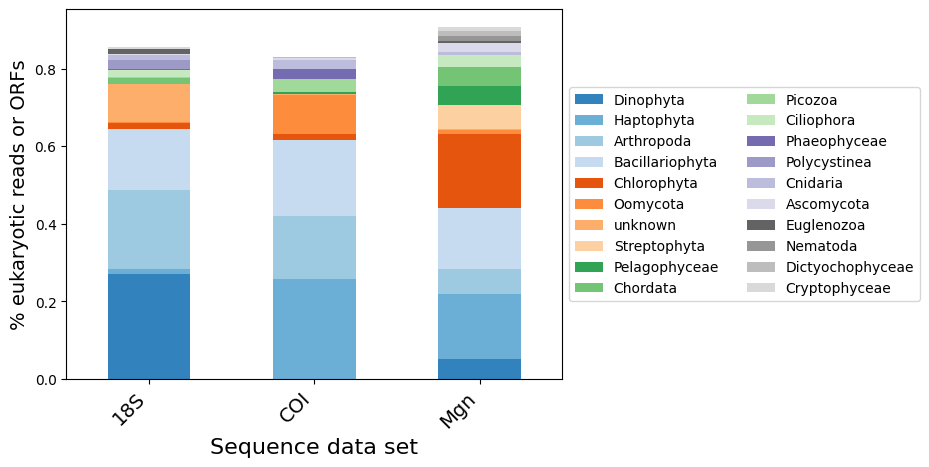

In [70]:
fig = plt.figure(figsize=(10,12))

# Set color map
cmap = plt.get_cmap('tab20c')

# Plot the bars
pivot_sub_sort.plot(kind='bar', stacked=True, cmap='tab20c')

# Put a legend to the right of the current axis
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2)

plt.ylabel('% eukaryotic reads or ORFs', size=14)
plt.xlabel('Sequence data set', size=16)
plt.xticks(rotation=45, ha='right', size=14)

# save the graph
plt.savefig('CCE_2018-2019_prok_vs_euk_relabund.png', format='png', 
            dpi=1200, bbox_inches='tight')

# show the graph
plt.show()

## 4. Compare genera between ASV data sets

#### Taxa seen in either ASV data set, or in both

In [47]:
phyla_genera_COI.shape 

(264, 4)

In [117]:
phyla_genera_18S_COI = pd.merge(phyla_genera_18S, phyla_genera_COI, 
                                on=['Phylum', 'Genus'], how='outer', 
                                indicator=True).drop(columns={'number of occurrences_x', 'number of occurrences_y', 'Data set_x', 'Data set_y'})
phyla_genera_18S_COI.head()

,Phylum,Genus,_merge
0,Acantharea,Acanthocolla,left_only
1,Acantharea,Acanthometra,left_only
2,Acantharea,Acanthostaurus,left_only
3,Acantharea,Amphibelone,left_only
4,Acantharea,Gigartacon,left_only


In [118]:
# Separate out 18S-only and COI-only observed genera
phyla_genera_18S_only = phyla_genera_18S_COI[phyla_genera_18S_COI['_merge'] == 'left_only'].drop(columns={'_merge'})
phyla_genera_COI_only = phyla_genera_18S_COI[phyla_genera_18S_COI['_merge'] == 'right_only'].drop(columns={'_merge'})

In [120]:
# Make dfs for genera seen in both 18S and COI, or in either one
phyla_genera_18S_COI_both = phyla_genera_18S_COI[phyla_genera_18S_COI['_merge'] == 'both'].drop(columns={'_merge'})
phyla_genera_18S_COI_either = phyla_genera_18S_COI.drop(columns={'_merge'})

#### Taxa seen in either 18S or COI

In [121]:
phyla_genera_18S_COI_either

,Phylum,Genus
0,Acantharea,Acanthocolla
1,Acantharea,Acanthometra
2,Acantharea,Acanthostaurus
3,Acantharea,Amphibelone
4,Acantharea,Gigartacon
...,...,...
724,unknown,Sticholonche
725,unknown,Telonema
726,unknown,Telonemia
727,unknown,g_


#### Taxa seen across all data sets including metagenomes

In [123]:
phyla_genera_mgns = phyla_genera_mgns.drop(columns={'number of occurrences'})
df_all = phyla_genera_mgns.merge(phyla_genera_18S_COI_either.drop_duplicates(), on=['Phylum','Genus'], 
                   how='outer', indicator=True).drop(columns={'Data set'})

In [124]:
phyla_genera_mgns.head()

,Phylum,Genus,Data set
0,Acantharea,Astrolonche,Mgn
1,Acantharea,Phyllostaurus,Mgn
2,Acantharea,Stauracon,Mgn
3,Acanthocephala,Pomphorhynchus,Mgn
4,Actinophryidae,Actinophrys,Mgn


In [129]:
phyla_genera_mgns.shape

(6231, 3)

In [132]:
df_all.head()

,Phylum,Genus,_merge
0,Acantharea,Acanthocolla,right_only
1,Acantharea,Acanthometra,right_only
2,Acantharea,Acanthostaurus,right_only
3,Acantharea,Amphibelone,right_only
4,Acantharea,Astrolonche,left_only


#### Taxa seen only in metagenomes

In [126]:
df_mgns_only = df_all[df_all['_merge'] == 'left_only']
df_mgns_only = df_mgns_only.drop(columns={'_merge'})
df_mgns_only['Data set'] = 'Mgn'
df_mgns_only.head()

,Phylum,Genus,Data set
4,Acantharea,Astrolonche,Mgn
13,Acanthocephala,Pomphorhynchus,Mgn
14,Actinophryidae,Actinophrys,Mgn
15,Actinophryidae,Actinosphaerium,Mgn
16,Ancyromonadida,Ancyromonas,Mgn


In [127]:
df_mgns_only.shape

(5921, 3)

### Only in 18S, COI, or 18S and COI, but NOT in metagenomes

#### 18S only

In [68]:
# phyla_genera_18S_only already excludes genera seen in COI
df_18S = phyla_genera_mgns.merge(phyla_genera_18S_only.drop_duplicates(), on=['Phylum','Genus'], 
                   how='outer', indicator=True)
df_18S_only = df_18S[df_18S['_merge'] == 'right_only'].drop(columns={'_merge'})
df_18S_only['Data set'] = '18S'
df_18S_only.shape

(277, 5)

#### COI only

In [69]:
df_COI = phyla_genera_mgns.merge(phyla_genera_COI_only.drop_duplicates(), on=['Phylum','Genus'], 
                   how='outer', indicator=True)
df_COI_only = df_COI[df_COI['_merge'] == 'right_only'].drop(columns={'_merge'})
df_COI_only['Data set'] = 'COI'
df_COI_only.shape

(90, 5)

#### ASVs only

In [70]:
df_asvs_only = df_all[df_all['_merge'] == 'right_only'].drop(columns={'_merge'})
df_asvs_only['Data set'] = '18S or COI'
df_asvs_only

,Phylum,Genus,Data set
0,Acantharea,Acanthocolla,18S or COI
1,Acantharea,Acanthometra,18S or COI
2,Acantharea,Acanthostaurus,18S or COI
3,Acantharea,Amphibelone,18S or COI
5,Acantharea,Gigartacon,18S or COI
...,...,...,...
6645,unknown,Sticholonche,18S or COI
6646,unknown,Telonema,18S or COI
6647,unknown,Telonemia,18S or COI
6648,unknown,g_,18S or COI


### 4a. Format data for plotting

In [134]:
def compare_taxa_across_data_sets(dfs):
    phy_gen_mgns = pd.concat(dfs)
    phy_gen_mgns['genus count'] = 1
    phy_gen_mgns = phy_gen_mgns.drop(columns='Genus').groupby(['Phylum', 'Data set']).sum()
    pivot = pd.pivot_table(data=phy_gen_mgns, 
                       index=['Data set'], 
                       columns=['Phylum'], 
                       values='genus count').fillna(0)
    return(phy_gen_mgns, pivot)

#### To compare total numbers across all data sets

In [133]:
dfs = [phyla_genera_mgns, phyla_genera_18S, phyla_genera_COI]

#### To compare genera seen only in certain data sets

In [123]:
dfs = [df_mgns_only, df_18S_only, df_COI_only, df_asvs_only]

### 4b. Make the stacked bar plot

In [135]:
phy_gen_mgns, pivot = compare_taxa_across_data_sets(dfs)

In [125]:
# for the genera exclusive to each data set
pivot = pivot.reindex(['18S', 'COI', '18S or COI', 'Mgn'])

In [136]:
pivot.head()

Phylum,Acantharea,Acanthocephala,Actinophryidae,Ancyromonadida,Annelida,Aphelidea,Apicomplexa,Apusomonadida,Arthropoda,Ascomycota,...,Streptophyta,Synurophyceae,Tardigrada,Telonemida,Tsukubamonadida,Tubulinea,Xanthophyceae,Xenacoelomorpha,Zoopagomycota,unknown
Data set,,,,,,,,,,,,,,,,,,,,,
18S,12.0,0.0,0.0,0.0,39.0,1.0,3.0,0.0,26.0,14.0,...,10.0,3.0,0.0,0.0,0.0,4.0,1.0,0.0,1.0,9.0
COI,0.0,0.0,0.0,0.0,22.0,0.0,1.0,0.0,35.0,7.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
Mgn,3.0,1.0,2.0,3.0,85.0,1.0,29.0,3.0,1521.0,423.0,...,772.0,6.0,7.0,1.0,1.0,12.0,7.0,9.0,24.0,0.0


In [141]:
pivot_sorted = pivot.sort_values(by=pivot.index[2], ascending=False, axis=1) # index[3] 
pivot_sorted.head()

Phylum,Arthropoda,Chordata,Streptophyta,Ascomycota,Rhodophyta,Bacillariophyta,Basidiomycota,Chlorophyta,Mollusca,Cnidaria,...,Gastrotricha,Prasinodermophyta,Phoronida,Sticholonchida,Developea,Hemimastigophora,Imbricatea,Picozoa,Sipuncula,unknown
Data set,,,,,,,,,,,,,,,,,,,,,
18S,26.0,20.0,10.0,14.0,2.0,40.0,9.0,21.0,7.0,40.0,...,1.0,2.0,0.0,0.0,2.0,1.0,7.0,3.0,1.0,9.0
COI,35.0,19.0,1.0,7.0,7.0,18.0,1.0,7.0,9.0,32.0,...,2.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0
Mgn,1521.0,1084.0,772.0,423.0,215.0,209.0,208.0,202.0,202.0,131.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [142]:
# Remove genera with a sum across all data sets of <100 and combine into "Other" column
pivot_sorted.loc['sum'] = pivot_sorted.sum()
pivot_sorted['total'] = pivot_sorted.sum(axis=1)
pivot_sorted_sub = []
for column in pivot_sorted.columns:
    if pivot_sorted[column].sum() > 100:
        pivot_sorted_sub.append(column)
pivot_sorted_sub = pivot_sorted[pivot_sorted_sub].drop(columns={'total'})
pivot_sorted_sub['new total'] = pivot_sorted_sub.sum(axis=1)
pivot_sorted_sub = pd.concat([pivot_sorted_sub, pivot_sorted['total']], axis=1)
pivot_sorted_sub['Other'] = pivot_sorted_sub['total'] - pivot_sorted_sub['new total']
pivot_sorted_sub = pivot_sorted_sub.drop(columns = {'new total', 'total'})
pivot_sorted_sub = pivot_sorted_sub.drop(['sum'])
pivot_sorted_sub

,Arthropoda,Chordata,Streptophyta,Ascomycota,Rhodophyta,Bacillariophyta,Basidiomycota,Chlorophyta,Mollusca,Cnidaria,Ciliophora,Annelida,Nematoda,Phaeophyceae,Dinophyceae,Porifera,Platyhelminthes,Mucoromycota,Euglenozoa,Other
Data set,,,,,,,,,,,,,,,,,,,,
18S,26.0,20.0,10.0,14.0,2.0,40.0,9.0,21.0,7.0,40.0,36.0,39.0,0.0,5.0,80.0,7.0,2.0,2.0,6.0,220.0
COI,35.0,19.0,1.0,7.0,7.0,18.0,1.0,7.0,9.0,32.0,1.0,22.0,0.0,4.0,10.0,6.0,1.0,1.0,0.0,83.0
Mgn,1521.0,1084.0,772.0,423.0,215.0,209.0,208.0,202.0,202.0,131.0,113.0,85.0,82.0,82.0,71.0,55.0,50.0,50.0,47.0,629.0


#### With an axis break

[Text(0, 0, '18S'), Text(1, 0, 'COI'), Text(2, 0, 'Metagenomes')]

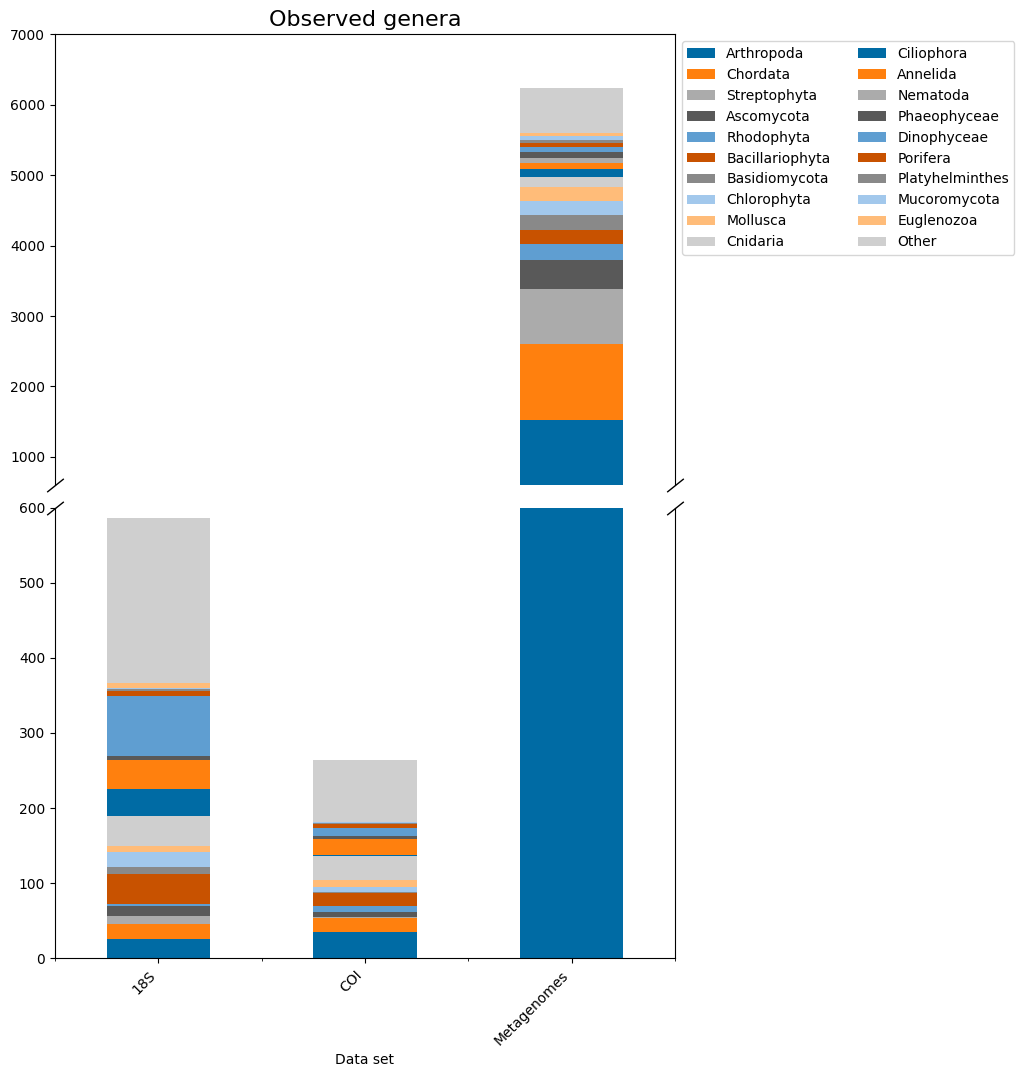

In [143]:
style.use('tableau-colorblind10')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8,12))
fig.subplots_adjust(hspace=0.05)  # adjust space between axes

# plot the same data on both axes
pivot_sorted_sub.plot(ax=ax1, kind='bar', stacked=True)
pivot_sorted_sub.plot(ax=ax2, kind='bar', stacked=True, legend=False)

# zoom-in / limit the view to different portions of the data
ax1.set_ylim(600, 7000)  # mgns
ax2.set_ylim(0, 600)  # asvs

# Hide the borders and generate break marks
ax1.spines["bottom"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.tick_params(axis="x", which="both", length=0)
#ax1.tick_params(labelbottom="off")
ax2.tick_params(labeltop="off")
ax2.xaxis.tick_bottom()

d = 0.8  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# This labels the bottom (largest) section of the metagenome bar
#ax1.bar_label(ax1.containers[0], fmt=lambda x: x if x > 0 else '', label_type='edge')

ax1.legend(bbox_to_anchor=(1, 1),
          ncol=2, fancybox=True)
ax1.set_title('Observed genera', fontsize=16)
ax2.set_xticklabels(['18S', 'COI', 'Metagenomes'], ha='right', rotation=45)

In [144]:
fig.savefig('Genera_exlusive_to_each_dataset_sub100.png', bbox_inches='tight')